<br/>
<img src="images/LOGO-CORREO_x.png" alt="SkillNest" width="280px" align="left"/>
<img src="images/LOGO-CORREO_x.png" alt="SkillNest" width="280px" align="right"/>
<div align="center">
<h2>Bootcamp Data Science — Módulo 2</h2><br/>
<h1>Semana 7 · Lunes — Introducción a Clasificación + KNN</h1>
<h3>De predecir números a predecir categorías</h3>
<br/>
    <b>Instructor:</b> Jesús Ortiz · jesus.jeduardo7@gmail.com<br/><br/>
    <b>SkillNest · b2b-sonda-data-science</b>
</div>
<br/>

## 🎯 Objetivos de hoy

1. Entender la **diferencia** entre regresión y clasificación.
2. Conocer los **3 tipos de clasificación**: binaria, multiclase, multilabel.
3. Implementar el **clasificador KNN** y sus parámetros clave.
4. Entender qué es una **función de distancia** (Euclidiana, Manhattan) y por qué importa.
5. Comprobar **numéricamente** por qué KNN exige estandarización.
6. Visualizar las **fronteras de decisión** de un clasificador.
7. Usar **Cross-Validation** para elegir hiperparámetros de forma honesta.
8. Resolver **3 ejercicios profundos** con datasets reales (Iris, Pima Diabetes y Breast Cancer).

> Esta semana es completamente nueva: **dejamos de predecir números y pasamos a predecir categorías**.

# 1. Regresión vs Clasificación

Hasta ahora predecíamos **valores continuos** (precios, edades, puntajes). Ahora vamos a predecir **categorías** (clases).

| Aspecto | Regresión | Clasificación |
|---|---|---|
| Target | Número continuo (precio = 152,000 USD) | Categoría (spam / no spam) |
| Métrica típica | MAE, RMSE, R² | Accuracy, Precision, Recall, F1 |
| Algoritmos | LinearRegression, Ridge, RF Regressor | LogisticRegression, KNN, RF Classifier |
| Pregunta | ¿Cuánto? | ¿De qué clase? |

### Tipos de clasificación

| Tipo | Ejemplo | # de clases |
|---|---|---|
| **Binaria** | ¿Spam o no spam? | 2 |
| **Multiclase** | ¿Especie de pingüino? Adelie / Chinstrap / Gentoo | >2 (excluyentes) |
| **Multilabel** | Etiquetar fotos: gato Y árbol Y cielo | >1 etiqueta a la vez |

> 💡 Hoy nos enfocamos en **clasificación multiclase con Iris** y **binaria con Pima Diabetes**.

# 2. KNN Clasificador — "dime quién es tu vecino"

### 🧠 La idea

Para clasificar un punto nuevo, KNN:

1. Busca los **k vecinos más cercanos** del training set.
2. Cuenta de qué clase son.
3. **Vota por mayoría** → la clase más común es la predicción.

### Diferencia con KNN regresor

| Aspecto | KNN Regresor | KNN Clasificador |
|---|---|---|
| Output | Promedio de los k vecinos | Voto mayoritario |
| Método | `.predict()` da número | `.predict()` da clase + `.predict_proba()` da probabilidades |

### Parámetros clave

| Parámetro | ¿Qué hace? |
|---|---|
| `n_neighbors` (k) | Número de vecinos a consultar |
| `weights` | `'uniform'` (todos pesan igual) o `'distance'` (vecinos más cercanos pesan más) |
| `metric` | Métrica de distancia (`'euclidean'` por defecto) |

> ⚠️ **KNN exige estandarizar SIEMPRE** porque usa distancias.

# 3. ¿Qué significa "vecino más cercano"? — La importancia de la DISTANCIA

KNN necesita medir **qué tan parecidos** son dos puntos. Para eso usa una **función de distancia**. Las 3 más comunes:

| Distancia | Fórmula | Cuándo usar |
|---|---|---|
| **Euclidiana** (default) | √(Σ(xi - yi)²) | Default para casi todo — la línea recta |
| **Manhattan** | Σ\|xi - yi\| | Cuando los movimientos solo pueden ser horizontales/verticales (calles de Manhattan) |
| **Minkowski** (general) | (Σ\|xi - yi\|ᵖ)^(1/p) | Generalización: p=2 → Euclidiana, p=1 → Manhattan |

### 🧠 Analogía

- **Euclidiana** = volar en helicóptero de un punto a otro (línea recta).
- **Manhattan** = caminar en una ciudad cuadriculada (solo norte/sur, este/oeste).

En sklearn se cambia con `metric='euclidean'` (default) o `metric='manhattan'`.

> 💡 La distancia más usada en clasificación tabular es **Euclidiana**. Manhattan brilla cuando trabajas con features que tienen escalas muy diferentes o son robustas a outliers.

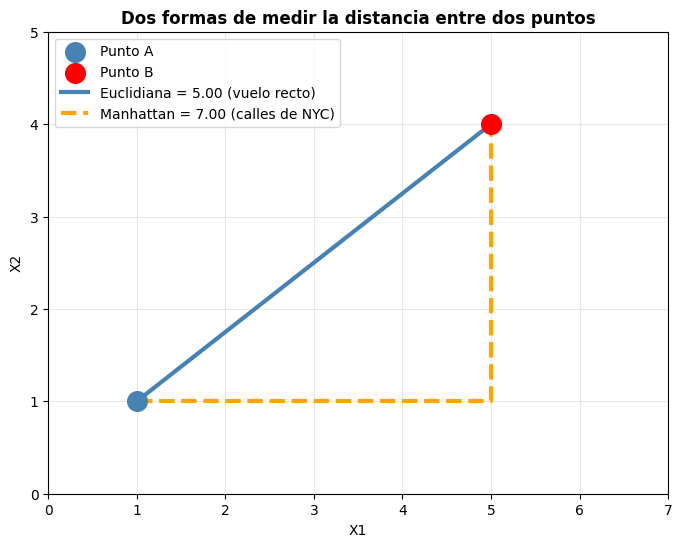

👉 Euclidiana es siempre MENOR o igual que Manhattan — la línea recta es el camino más corto.


In [1]:
# Visualicemos: dos puntos en un plano y las distintas distancias entre ellos
import numpy as np
import matplotlib.pyplot as plt

p1 = np.array([1, 1])
p2 = np.array([5, 4])

euclidiana = np.sqrt(((p1 - p2)**2).sum())   # = √(16+9) = 5
manhattan  = np.abs(p1 - p2).sum()            # = 4+3 = 7

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(*p1, s=200, color='steelblue', zorder=3, label='Punto A')
ax.scatter(*p2, s=200, color='red',       zorder=3, label='Punto B')

# Línea Euclidiana (línea recta)
ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color='steelblue', linewidth=3,
        label=f'Euclidiana = {euclidiana:.2f} (vuelo recto)')

# Línea Manhattan (escalones)
ax.plot([p1[0], p2[0], p2[0]], [p1[1], p1[1], p2[1]], color='orange',
        linewidth=3, linestyle='--',
        label=f'Manhattan = {manhattan:.2f} (calles de NYC)')

ax.set_xlim(0, 7); ax.set_ylim(0, 5)
ax.set_xlabel('X1'); ax.set_ylabel('X2')
ax.set_title('Dos formas de medir la distancia entre dos puntos', fontweight='bold')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
plt.show()

print('👉 Euclidiana es siempre MENOR o igual que Manhattan — la línea recta es el camino más corto.')

# 4. ⚠️ Por qué KNN OBLIGA a estandarizar — DEMO numérica

KNN suma diferencias de TODAS las features para calcular distancia. Si una feature tiene rango 0–100 y otra 0–1.000.000, la segunda **domina por completo** las distancias, aunque sea menos predictiva.

Vamos a verlo con un experimento:

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
# Vamos a simular un dataset binario con 2 features de escalas MUY distintas
np.random.seed(42)
n = 200
# Feature 1: rango 0-1
f1 = np.random.uniform(0, 1, n)
# Feature 2: rango 0-100,000 (tipo "salario en pesos")
f2 = np.random.uniform(0, 100_000, n)
# La clase REAL depende solo de f1 (f2 es ruido)
y_demo = (f1 > 0.5).astype(int)

X_demo = np.column_stack([f1, f2])
X_demo_train, X_demo_test, y_demo_train, y_demo_test = train_test_split(
    X_demo, y_demo, test_size=0.3, random_state=42, stratify=y_demo
)

In [8]:
# KNN SIN estandarizar
knn_sin = KNeighborsClassifier(n_neighbors=5).fit(X_demo_train, y_demo_train)
acc_sin = knn_sin.score(X_demo_test, y_demo_test)
print(f'Accuracy SIN estandarizar:  {acc_sin:.4f}  ← f2 dominó la distancia, modelo ROTO')

Accuracy SIN estandarizar:  0.4167  ← f2 dominó la distancia, modelo ROTO


In [9]:
# KNN CON estandarización
sc_demo = StandardScaler()
knn_con = KNeighborsClassifier(n_neighbors=5).fit(sc_demo.fit_transform(X_demo_train), y_demo_train)
acc_con = knn_con.score(sc_demo.transform(X_demo_test), y_demo_test)
print(f'Accuracy CON estandarizar:  {acc_con:.4f}  ← f1 (la que importa) recupera su peso')


Accuracy CON estandarizar:  0.9167  ← f1 (la que importa) recupera su peso


In [10]:
print(f'\nDiferencia: {(acc_con - acc_sin)*100:.1f} puntos porcentuales 🚨')


Diferencia: 50.0 puntos porcentuales 🚨


In [ ]:
# Vamos a simular un dataset binario con 2 features de escalas MUY distintas
np.random.seed(42)
n = 200
# Feature 1: rango 0-1
f1 = np.random.uniform(0, 1, n)
# Feature 2: rango 0-100,000 (tipo "salario en pesos")
f2 = np.random.uniform(0, 100_000, n)
# La clase REAL depende solo de f1 (f2 es ruido)
y_demo = (f1 > 0.5).astype(int)

X_demo = np.column_stack([f1, f2])
X_demo_train, X_demo_test, y_demo_train, y_demo_test = train_test_split(
    X_demo, y_demo, test_size=0.3, random_state=42, stratify=y_demo
)

# KNN SIN estandarizar
knn_sin = KNeighborsClassifier(n_neighbors=5).fit(X_demo_train, y_demo_train)
acc_sin = knn_sin.score(X_demo_test, y_demo_test)

# KNN CON estandarización
sc_demo = StandardScaler()
knn_con = KNeighborsClassifier(n_neighbors=5).fit(sc_demo.fit_transform(X_demo_train), y_demo_train)
acc_con = knn_con.score(sc_demo.transform(X_demo_test), y_demo_test)

print(f'Accuracy SIN estandarizar:  {acc_sin:.4f}  ← f2 dominó la distancia, modelo ROTO')
print(f'Accuracy CON estandarizar:  {acc_con:.4f}  ← f1 (la que importa) recupera su peso')
print(f'\nDiferencia: {(acc_con - acc_sin)*100:.1f} puntos porcentuales 🚨')

## 👀 Demo en vivo — KNN sobre Iris (multiclase)

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Dataset clásico de iris
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/iris.csv'
cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
df = pd.read_csv(url, names=cols)

print(f'Shape: {df.shape}')
print(f'Clases: {df["species"].value_counts().to_dict()}')
df.head()

Shape: (150, 5)
Clases: {'Iris-setosa': 50, 'Iris-versicolor': 50, 'Iris-virginica': 50}


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [12]:
X = df.drop(columns=['species'])
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# stratify=y → mantiene la proporción de clases en train y test (CRÍTICO en clasificación)

sc = StandardScaler()
X_train_esc = sc.fit_transform(X_train)
X_test_esc  = sc.transform(X_test)

In [13]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_esc, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [15]:
y_pred = knn.predict(X_test_esc)
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(f'\nPredicciones primeras 5:')
for real, pred in zip(y_test[:5], y_pred[:5]):
    print(f'  Real: {real:15s} → Predicho: {pred}')

Accuracy: 0.9333

Predicciones primeras 5:
  Real: Iris-setosa     → Predicho: Iris-setosa
  Real: Iris-virginica  → Predicho: Iris-virginica
  Real: Iris-versicolor → Predicho: Iris-versicolor
  Real: Iris-versicolor → Predicho: Iris-versicolor
  Real: Iris-setosa     → Predicho: Iris-setosa


In [ ]:
X = df.drop(columns=['species'])
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# stratify=y → mantiene la proporción de clases en train y test (CRÍTICO en clasificación)

sc = StandardScaler()
X_train_esc = sc.fit_transform(X_train)
X_test_esc  = sc.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_esc, y_train)

y_pred = knn.predict(X_test_esc)
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(f'\nPredicciones primeras 5:')
for real, pred in zip(y_test[:5], y_pred[:5]):
    print(f'  Real: {real:15s} → Predicho: {pred}')

In [16]:
# probabilidades por clase — algo que la regresión no tiene
probas = knn.predict_proba(X_test_esc[:5])
df_probas = pd.DataFrame(probas, columns=knn.classes_)
df_probas['Predicción'] = knn.predict(X_test_esc[:5])
df_probas['Real']       = y_test[:5].values
df_probas.round(2)

,Iris-setosa,Iris-versicolor,Iris-virginica,Predicción,Real
0,1.0,0.0,0.0,Iris-setosa,Iris-setosa
1,0.0,0.4,0.6,Iris-virginica,Iris-virginica
2,0.0,1.0,0.0,Iris-versicolor,Iris-versicolor
3,0.0,1.0,0.0,Iris-versicolor,Iris-versicolor
4,1.0,0.0,0.0,Iris-setosa,Iris-setosa


/var/folders/g_/vcnnmwh97_x01xg41ybpxmb00000gn/T/ipykernel_4163/1687083166.py:23: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  ax.legend(*scatter.legend_elements(), labels=list(df['species'].unique()))


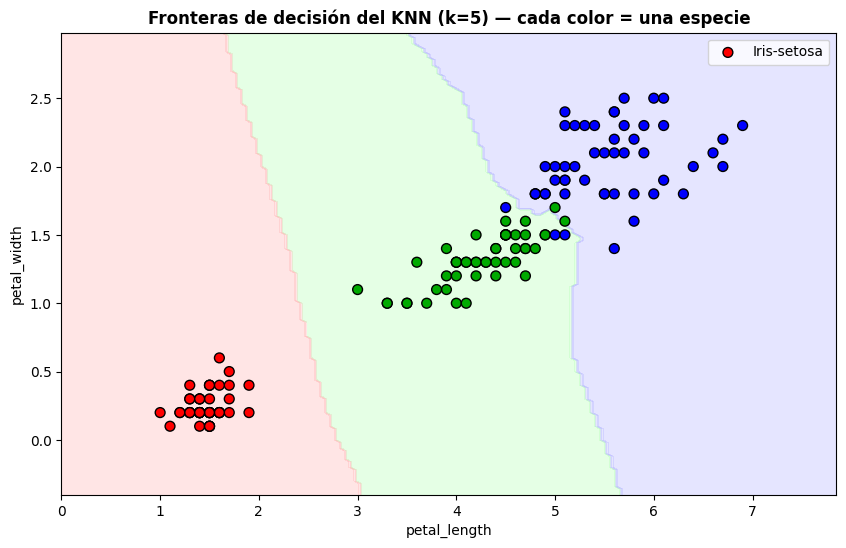

In [17]:
# Visualizar las FRONTERAS DE DECISIÓN usando 2 features
# (esto es el superpoder visual de KNN — se ve cómo decide)
from matplotlib.colors import ListedColormap

X2 = df[['petal_length', 'petal_width']].values
y2 = pd.factorize(df['species'])[0]  # convertir clases a 0,1,2

knn2 = KNeighborsClassifier(n_neighbors=5).fit(X2, y2)

# Crear malla
x_min, x_max = X2[:,0].min()-1, X2[:,0].max()+1
y_min, y_max = X2[:,1].min()-0.5, X2[:,1].max()+0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05), np.arange(y_min, y_max, 0.02))
Z = knn2.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(10, 6))
ax.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(['#FFAAAA','#AAFFAA','#AAAAFF']))
scatter = ax.scatter(X2[:,0], X2[:,1], c=y2, cmap=ListedColormap(['#FF0000','#00AA00','#0000FF']),
                      edgecolor='black', s=50)
ax.set_xlabel('petal_length')
ax.set_ylabel('petal_width')
ax.set_title('Fronteras de decisión del KNN (k=5) — cada color = una especie', fontweight='bold')
ax.legend(*scatter.legend_elements(), labels=list(df['species'].unique()))
plt.show()

## ⚙️ Tuning de k — ¿cuántos vecinos?

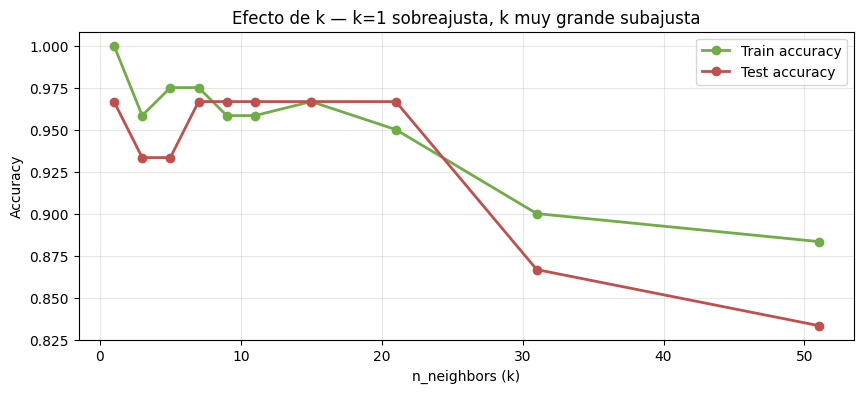

👉 Con k=1 el train siempre da 1.0 (memoriza), pero test puede caer → overfitting.
   Con k muy grande, ambos bajan → underfitting.


In [18]:
ks = [1, 3, 5, 7, 9, 11, 15, 21, 31, 51]
scores_train, scores_test = [], []
for k in ks:
    m = KNeighborsClassifier(n_neighbors=k).fit(X_train_esc, y_train)
    scores_train.append(m.score(X_train_esc, y_train))
    scores_test.append(m.score(X_test_esc, y_test))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ks, scores_train, marker='o', linewidth=2, color='#70AD47', label='Train accuracy')
ax.plot(ks, scores_test, marker='o', linewidth=2, color='#C0504D', label='Test accuracy')
ax.set_xlabel('n_neighbors (k)'); ax.set_ylabel('Accuracy')
ax.set_title('Efecto de k — k=1 sobreajusta, k muy grande subajusta')
ax.legend(); ax.grid(alpha=0.3)
plt.show()

print('👉 Con k=1 el train siempre da 1.0 (memoriza), pero test puede caer → overfitting.')
print('   Con k muy grande, ambos bajan → underfitting.')

# 5. 🎯 Cross-Validation — la forma honesta de elegir k

El gráfico anterior tiene un problema: estamos eligiendo k mirando UN SOLO split del test set. Si nos hubiera tocado otro split, podríamos elegir un k distinto. Eso es **azar**, no rigor.

**La solución:** Cross-Validation (CV).

### 🧠 Cómo funciona K-Fold CV

1. Dividimos el TRAIN en **K partes** (típicamente 5).
2. Entrenamos K veces: cada vez usamos K-1 partes para entrenar y 1 para validar.
3. Promediamos los K resultados → estimación **estable** del rendimiento real.

Esto se llama **5-fold cross-validation** y es el estándar para tunear hiperparámetros.

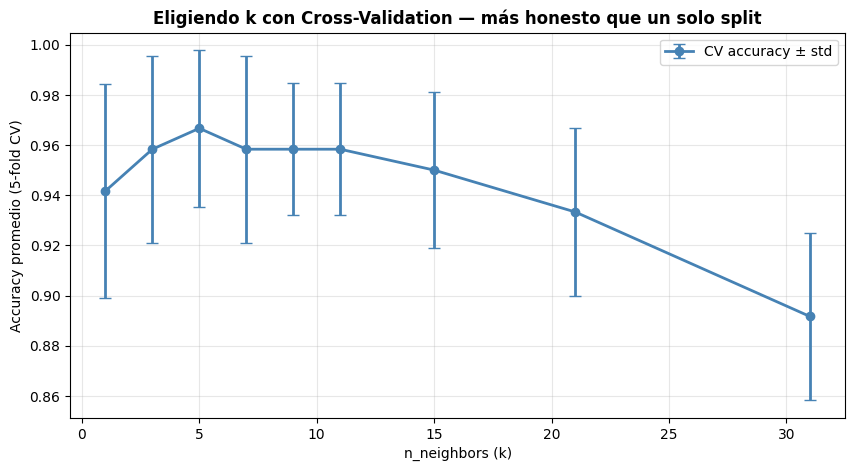

🏆 Mejor k según CV: 5 con accuracy promedio = 0.9667
   Las barras muestran la variabilidad entre los 5 folds — si son grandes, el modelo es inestable.


In [19]:
# Vamos a elegir k de forma HONESTA usando cross_val_score
from sklearn.model_selection import cross_val_score

ks = [1, 3, 5, 7, 9, 11, 15, 21, 31]
medias, desvios = [], []

for k in ks:
    # cross_val_score entrena K modelos y devuelve K scores
    scores = cross_val_score(
        KNeighborsClassifier(n_neighbors=k),
        X_train_esc, y_train,
        cv=5, scoring='accuracy'
    )
    medias.append(scores.mean())
    desvios.append(scores.std())

# Graficar con barras de error (media ± desviación)
fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(ks, medias, yerr=desvios, marker='o', linewidth=2,
            color='steelblue', capsize=4, label='CV accuracy ± std')
ax.set_xlabel('n_neighbors (k)')
ax.set_ylabel('Accuracy promedio (5-fold CV)')
ax.set_title('Eligiendo k con Cross-Validation — más honesto que un solo split', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.show()

mejor_k = ks[np.argmax(medias)]
print(f'🏆 Mejor k según CV: {mejor_k} con accuracy promedio = {max(medias):.4f}')
print('   Las barras muestran la variabilidad entre los 5 folds — si son grandes, el modelo es inestable.')

---
# 🏋️ Ejercicios profundos

## 🌸 Ejercicio 1 — KNN multiclase con Iris (varias decisiones)

**Tarea integradora.** Quiero que vayas más allá del tutorial.

**Dataset:**
```python
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/iris.csv'
cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
df = pd.read_csv(url, names=cols)
```

**Parte A — Comparación con y SIN estandarización**
1. Entrenar 2 KNNs (k=5): uno con `StandardScaler`, otro sin escalar nada.
2. Reportar accuracy de cada uno. ¿Qué diferencia hay y por qué?

**Parte B — Búsqueda del mejor k**
3. Loop sobre k = [1, 3, 5, 7, 9, 11, 15, 21, 31].
4. Graficar accuracy de train Y test.
5. Encontrar el k óptimo y argumentarlo.

**Parte C — Efecto del peso de los vecinos**
6. Con el mejor k, probar `weights='uniform'` vs `weights='distance'`. ¿Cambia el resultado?

**Parte D — Predicción y probabilidades**
7. Predecir la especie de estas 2 flores nuevas:
   ```python
   flores = pd.DataFrame([
       {'sepal_length': 5.1, 'sepal_width': 3.5, 'petal_length': 1.4, 'petal_width': 0.2},
       {'sepal_length': 6.7, 'sepal_width': 3.0, 'petal_length': 5.2, 'petal_width': 2.3}
   ])
   ```
8. Mostrar las **probabilidades por clase** de cada predicción con `predict_proba()`.

**Parte E — Conclusión**
9. ¿Qué clase es más difícil de predecir? (pista: mira la matriz de confusión)
10. ¿Cuál sería tu modelo final y por qué?

In [ ]:
# Parte A — Con y sin estandarización 👇



In [ ]:
# Parte B + C — Tuning de k y de weights 👇



In [ ]:
# Parte D + E — Predicción + matriz de confusión + conclusión 👇



## 🩺 Ejercicio 2 — KNN binario con Pima Diabetes (clases desbalanceadas)

Trabajas en un hospital. Te dan datos de 768 mujeres del grupo Pima Indians con varias mediciones médicas y si tienen diabetes. Tu misión: predecir si una paciente nueva tiene diabetes.

**Dataset:**
```python
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'
cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigree', 'Age', 'Outcome']
df = pd.read_csv(url, names=cols)
```

**Target:** `Outcome` (0 = sana, 1 = diabetes). ⚠️ **Clases desbalanceadas:** ~65% sanas, ~35% con diabetes.

**Parte A — Exploración**
1. Cargar y revisar `.info()`, `.describe()`.
2. ¿Cuál es la proporción de clases?
3. **Truco oculto del dataset:** varias columnas tienen `0` que NO es un cero válido (ej. `Glucose=0` o `BMI=0` es imposible — son nulos disfrazados). Identificar cuáles y **reemplazarlos por NaN**.

**Parte B — Pipeline limpio**
4. Imputar los nulos (mediana) y estandarizar.
5. Train/test split 80/20 con `stratify=y` (mantiene la proporción de clases).

**Parte C — KNN + tuning**
6. Entrenar `KNeighborsClassifier` y hacer GridSearchCV sobre:
   - `n_neighbors`: [3, 5, 7, 11, 15, 21, 31]
   - `weights`: ['uniform', 'distance']
7. Reportar mejores hiperparámetros + accuracy en test.

**Parte D — Análisis crítico**
8. Calcular y mostrar la **matriz de confusión**.
9. ¿Cuántos **falsos negativos** hay? En medicina: un falso negativo = paciente con diabetes que el modelo dice estar sana → **NO RECIBE TRATAMIENTO**. ¿Qué tan grave es esto?
10. Si tuvieras que entregar este modelo a un hospital, ¿lo entregarías? ¿Qué mejorarías?

> 💡 Mañana veremos métricas que entienden el desbalance (precision, recall, F1, AUC). Hoy solo accuracy + matriz.

In [ ]:
# Parte A — Exploración + truco de los ceros 👇



In [ ]:
# Parte B + C — Pipeline + GridSearchCV 👇



In [ ]:
# Parte D — Matriz de confusión + análisis crítico 👇



## 🎗️ Ejercicio 3 — Detección de cáncer de mama (DESAFÍO)

Trabajas en investigación oncológica. Te dan datos de 569 tumores de mama, cada uno con 30 mediciones físicas (radio, textura, perímetro, área, etc.). Tu misión: predecir si un tumor es **maligno (cáncer) o benigno**.

**Dataset (viene built-in con sklearn — sin necesidad de URL):**
```python
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer(as_frame=True)
X = data.data
y = data.target  # 0 = maligno, 1 = benigno
```

> ⚠️ Atención al mapeo de clases: `0 = maligno` (positivo médicamente), `1 = benigno` (negativo). El "positivo" en clasificación binaria por convención es la clase de interés. Aquí queremos detectar el cáncer.

**Parte A — Exploración + balance de clases**
1. Cargar el dataset y revisar `X.shape`, `y.value_counts()`.
2. ¿Cuál es la proporción de malignos vs benignos? ¿Está balanceado?
3. Hacer un **heatmap de correlación** de las primeras 10 features. ¿Hay features muy correlacionadas? (Pista: muchas mediciones de tamaño correlacionan entre sí.)

**Parte B — Pipeline + tuning con cross-validation**
4. Train/test 80/20 con `stratify=y` y `random_state=42`.
5. Pipeline: `StandardScaler` + `KNeighborsClassifier`.
6. Usar `cross_val_score` para evaluar k = [3, 5, 7, 9, 11, 15, 21, 31, 51] con cv=5.
7. Graficar accuracy promedio (con barras de error) vs k.
8. Elegir el mejor k.

**Parte C — Comparar métricas SIN y CON estandarización**
9. Entrenar 2 modelos con el k ganador: uno con StandardScaler, otro sin.
10. Reportar accuracy de ambos. ¿Cuánto pierde el modelo sin estandarizar? (con 30 features de escalas distintas, la diferencia será BRUTAL).

**Parte D — Matriz de confusión + interpretación médica**
11. Entrenar el modelo ganador y mostrar la matriz de confusión.
12. **Identificar los Falsos Negativos** (tumor maligno predicho como benigno → paciente NO recibe tratamiento). ¿Cuántos hay?
13. ¿Este modelo es aceptable para uso clínico? Justifica.

**Parte E — Tuning con métrica Manhattan**
14. Probar el mismo modelo cambiando `metric='euclidean'` por `metric='manhattan'`.
15. ¿Cambia la accuracy? ¿En qué escenarios podrías preferir Manhattan?

In [ ]:
# Parte A — Exploración 👇



In [ ]:
# Parte B + C — Pipeline + tuning con cross-validation + comparación estandarizado 👇



In [ ]:
# Parte D + E — Matriz de confusión + Manhattan vs Euclidiana 👇



---
## 📌 Cierre del día

- ✅ Diferencia clave: clasificación predice **categorías**, no números.
- ✅ KNN clasificador vota por mayoría entre los k vecinos más cercanos.
- ✅ **Distancias:** Euclidiana (default) y Manhattan — eligen cómo se mide "cercanía".
- ✅ Estandarizar es **OBLIGATORIO** (lo demostramos con números: una sola feature de escala distinta arruina el modelo).
- ✅ `stratify=y` en el split mantiene la proporción de clases.
- ✅ `predict_proba()` da probabilidades por clase — útil en problemas donde no basta con la clase ganadora.
- ✅ Las **fronteras de decisión** son una forma visual potente de explicar cómo clasifica un modelo.
- ✅ **Cross-Validation** (5-fold) es la forma profesional de elegir hiperparámetros sin depender del azar del split.

### 🔜 Mañana — Martes 2 de junio

Métricas de clasificación: **accuracy es engañosa** con clases desbalanceadas. Vamos a aprender precision, recall, F1, matriz de confusión y ROC-AUC.